# Import libraries and data

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import RandomOverSampler

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Load the data
meds = pd.read_csv('C:/Users/Katlego/OneDrive/Desktop/Data/CSIS3754/medicine.csv')

print("Data loaded successfully.")
print(f"Dataset shape: {meds.shape}")

Data loaded successfully.
Dataset shape: (200, 6)


# Inspect the data by: 

In [2]:
# 2.2.1 Display the first 20 records
print("="*60)
print("FIRST 20 RECORDS")
print("="*60)
print(meds.head(20))

# 2.2.2 Generate a statistical summary of all features
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(meds.describe())

# 2.2.3 Concise summary of the dataframe
print("\n" + "="*60)
print("DATAFRAME INFO")
print("="*60)
print(meds.info())

# 2.2.4 Check for missing values
print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
print(meds.isnull().sum())

FIRST 20 RECORDS
    Age  Gender Blood_Presure Cholesterol  Ratio_Na_K Medication
0    23  Female          High        High      25.355      meds5
1    47    Male           Low        High      13.093      meds3
2    47    Male           Low        High      10.114      meds3
3    28  Female        Normal        High       7.798      meds4
4    61  Female           Low        High      18.043      meds5
5    22  Female        Normal        High       8.607      meds4
6    49  Female        Normal        High      16.275      meds5
7    41    Male           Low        High      11.037      meds3
8    60    Male        Normal        High      15.171      meds5
9    43    Male           Low      Normal      19.368      meds5
10   47  Female           Low        High      11.767      meds3
11   34  Female          High      Normal      19.199      meds5
12   43    Male           Low        High      15.376      meds5
13   74  Female           Low        High      20.942      meds5
14   50 

# Visualise the data: 

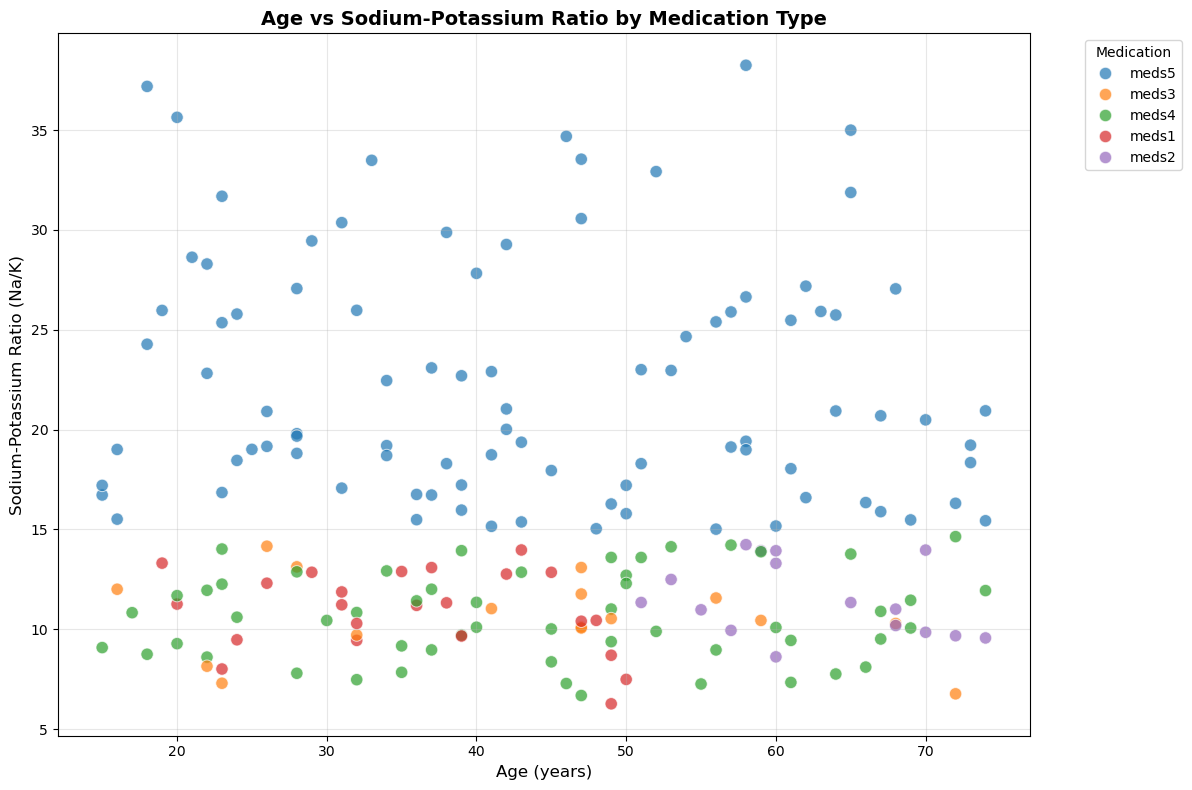

In [3]:
# Create a combined scatter plot
plt.figure(figsize=(12, 8))
sns.scatterplot(data=meds, x='Age', y='Ratio_Na_K', hue='Medication', s=80, alpha=0.7)
plt.title('Age vs Sodium-Potassium Ratio by Medication Type', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Sodium-Potassium Ratio (Na/K)', fontsize=12)
plt.legend(title='Medication', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation of scatter plot:

In [4]:
print("""
From the scatter plot the following can be deduced about medication efficacy:

1. meds5 (the most prescribed medication) is effective for patients with a 
   HIGH Ratio_Na_K (sodium-to-potassium ratio above ~15), regardless of age. 
   This suggests Ratio_Na_K is a strong predictor for meds5.

2. meds4 appears to cluster for patients with a LOW-to-MEDIUM Ratio_Na_K 
   and tends to be prescribed to older patients.

3. meds1, meds2, and meds3 occupy the lower Ratio_Na_K range. 
   These medications are differentiated more by the patient's age 
   than by their Na_K ratio alone.

4. Overall, the Ratio_Na_K appears to be the most important feature in 
   determining which medication is effective — there is a clear 
   horizontal separation in the scatter plot between meds5 and the others.
""")


From the scatter plot the following can be deduced about medication efficacy:

1. meds5 (the most prescribed medication) is effective for patients with a 
   HIGH Ratio_Na_K (sodium-to-potassium ratio above ~15), regardless of age. 
   This suggests Ratio_Na_K is a strong predictor for meds5.

2. meds4 appears to cluster for patients with a LOW-to-MEDIUM Ratio_Na_K 
   and tends to be prescribed to older patients.

3. meds1, meds2, and meds3 occupy the lower Ratio_Na_K range. 
   These medications are differentiated more by the patient's age 
   than by their Na_K ratio alone.

4. Overall, the Ratio_Na_K appears to be the most important feature in 
   determining which medication is effective — there is a clear 
   horizontal separation in the scatter plot between meds5 and the others.



# The number of records relevant to each medication. 

In [5]:
medication_counts = meds['Medication'].value_counts()
print(medication_counts)

Medication
meds5    91
meds4    54
meds1    23
meds3    16
meds2    16
Name: count, dtype: int64


# Balance check:

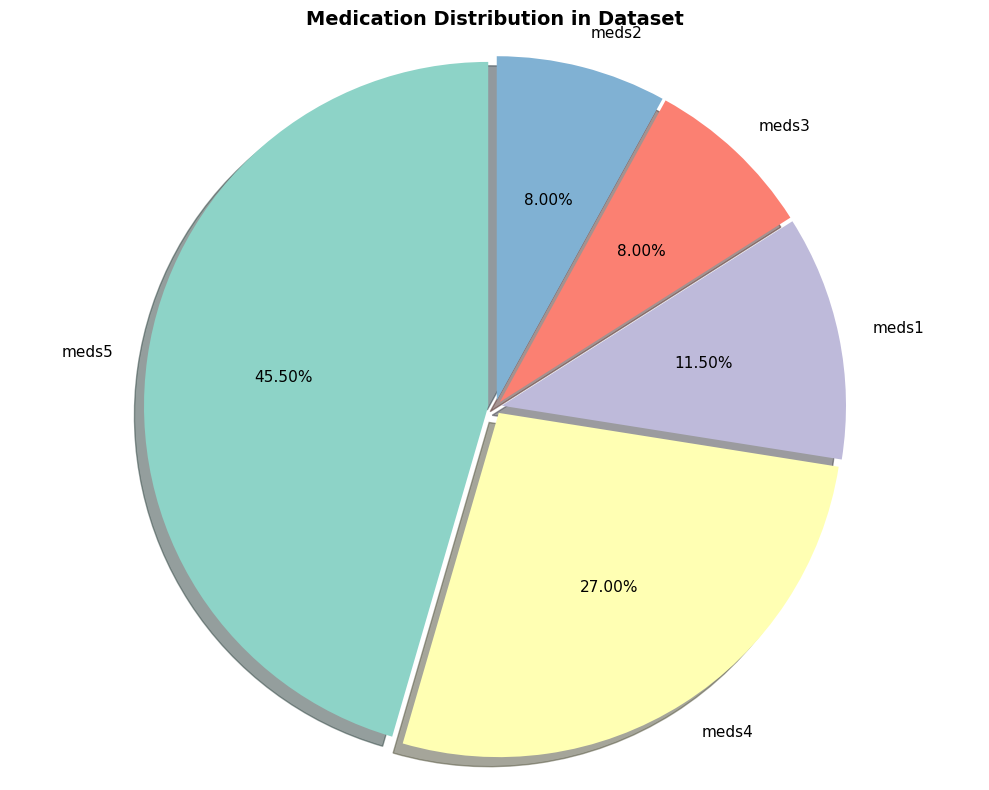


Smallest class size: 16
Largest class size: 91
Ratio (min/max): 0.176

⚠️ The dataset is IMBALANCED. Oversampling is recommended.


In [6]:
# Create pie chart
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(medication_counts)))
plt.pie(medication_counts.values, 
        labels=medication_counts.index, 
        autopct='%.2f%%',
        colors=colors,
        startangle=90,
        explode=[0.02] * len(medication_counts),
        shadow=True,
        textprops={'fontsize': 11})
plt.title('Medication Distribution in Dataset', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Calculate balance metrics
min_count = medication_counts.min()
max_count = medication_counts.max()
ratio = min_count / max_count

print(f"\nSmallest class size: {min_count}")
print(f"Largest class size: {max_count}")
print(f"Ratio (min/max): {ratio:.3f}")

if ratio < 0.8:
    print("\n⚠️ The dataset is IMBALANCED. Oversampling is recommended.")
else:
    print("\n✓ The dataset is relatively balanced.")

In [7]:
print("""
The data is clearly IMBALANCED. meds5 accounts for approximately 45.5% of all 
records, while meds2 and meds3 each account for only about 8%. This imbalance 
means a classifier could achieve high accuracy simply by always predicting meds5, 
without learning the actual distinguishing patterns. Oversampling is required.
""")



The data is clearly IMBALANCED. meds5 accounts for approximately 45.5% of all 
records, while meds2 and meds3 each account for only about 8%. This imbalance 
means a classifier could achieve high accuracy simply by always predicting meds5, 
without learning the actual distinguishing patterns. Oversampling is required.



#  operations to balance the data

In [8]:
print("="*60)
print("BALANCING DATA USING OVERSAMPLING")
print("="*60)

# Separate features and target
X = meds.drop('Medication', axis=1)
y = meds['Medication']

print(f"Before oversampling:")
print(f"  X shape: {X.shape}")
print(f"  y distribution:")
print(f"    {y.value_counts().to_string()}")

# Apply oversampling
oversampler = RandomOverSampler(random_state=42, sampling_strategy='auto')
X_resampled, y_resampled = oversampler.fit_resample(X, y)

# Create the resampled dataframe
meds_resampled = pd.DataFrame(X_resampled, columns=X.columns)
meds_resampled['Medication'] = y_resampled

print(f"\nAfter oversampling:")
print(f"  X_resampled shape: {X_resampled.shape}")
print(f"  y_resampled distribution:")
print(f"    {y_resampled.value_counts().to_string()}")

print(f"\n✓ Oversampling completed successfully.")
print(f"  All medication classes now have equal representation.")

BALANCING DATA USING OVERSAMPLING
Before oversampling:
  X shape: (200, 5)
  y distribution:
    Medication
meds5    91
meds4    54
meds1    23
meds3    16
meds2    16

After oversampling:
  X_resampled shape: (455, 5)
  y_resampled distribution:
    Medication
meds5    91
meds3    91
meds4    91
meds1    91
meds2    91

✓ Oversampling completed successfully.
  All medication classes now have equal representation.


# Confirm the successful resampling of the data

Records per medication after resampling:
Medication
meds5    91
meds3    91
meds4    91
meds1    91
meds2    91
Name: count, dtype: int64


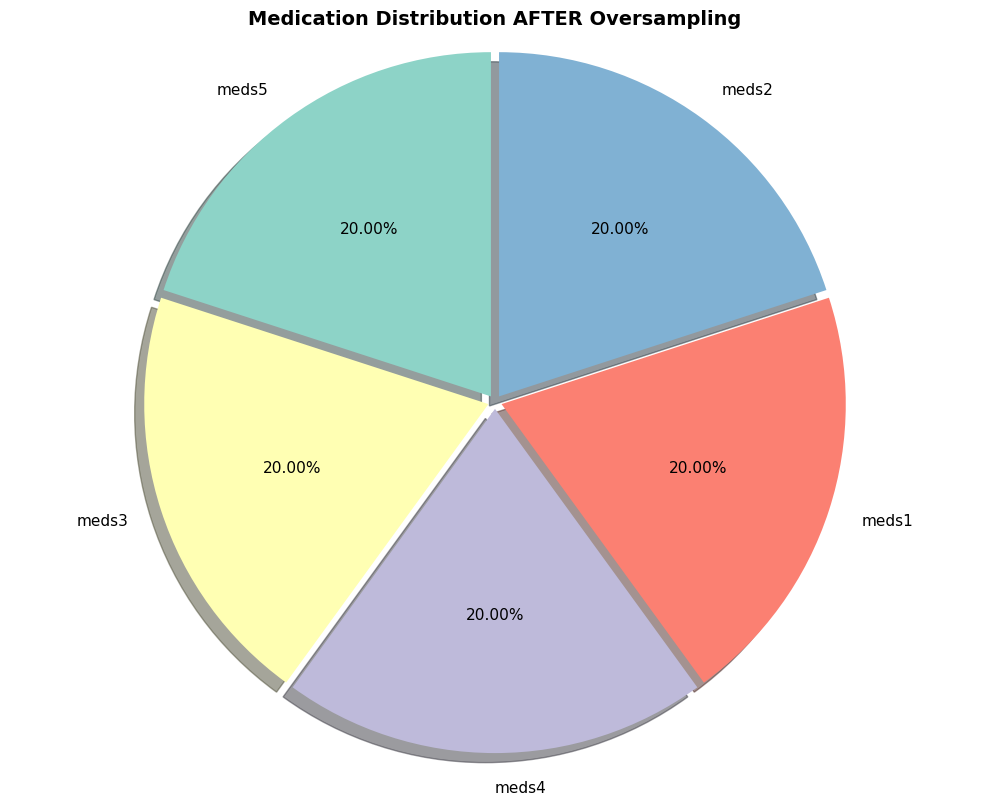


✓ CONFIRMATION: All medication classes now have exactly equal representation.


In [9]:
# Display number of records per medication
resampled_counts = meds_resampled['Medication'].value_counts()
print("Records per medication after resampling:")
print(resampled_counts)

# Recreate pie chart
plt.figure(figsize=(10, 8))
plt.pie(resampled_counts.values, 
        labels=resampled_counts.index, 
        autopct='%.2f%%',
        colors=colors,
        startangle=90,
        explode=[0.02] * len(resampled_counts),
        shadow=True,
        textprops={'fontsize': 11})
plt.title('Medication Distribution AFTER Oversampling', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

print("\n✓ CONFIRMATION: All medication classes now have exactly equal representation.")

# Convert text values to numeric

In [10]:
# Make a copy to work with
meds_encoded = meds_resampled.copy()

# Identify columns with text values (object type)
object_columns = meds_encoded.select_dtypes(include=['object']).columns.tolist()
print(f"Columns with text values: {object_columns}")

# Separate target from features (we'll encode target separately)
if 'Medication' in object_columns:
    object_columns.remove('Medication')

# 2.9.1 Convert binary columns (2 unique values) to [0, 1]
binary_cols = []
multi_cols = []

for col in object_columns:
    unique_count = meds_encoded[col].nunique()
    if unique_count == 2:
        binary_cols.append(col)
    else:
        multi_cols.append(col)

print(f"\nBinary columns (2 unique values): {binary_cols}")
print(f"Multi-class columns (>2 unique values): {multi_cols}")

# Convert binary columns
for col in binary_cols:
    unique_vals = meds_encoded[col].unique()
    mapping = {unique_vals[0]: 0, unique_vals[1]: 1}
    meds_encoded[col] = meds_encoded[col].map(mapping)
    print(f"  Encoded {col}: {mapping}")

# 2.9.2 Convert multi-class columns to numeric values [0, 1, 2, ..., n]
for col in multi_cols:
    # Use LabelEncoder to convert to numeric
    le = LabelEncoder()
    meds_encoded[col] = le.fit_transform(meds_encoded[col])
    print(f"  Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# 2.9.3 Encode the target variable (for correlation analysis)
le_target = LabelEncoder()
meds_encoded['Medication_Code'] = le_target.fit_transform(meds_encoded['Medication'])
target_mapping = dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))
print(f"\n  Target (Medication) encoded: {target_mapping}")

print("\n✓ Text to numeric conversion completed.")

Columns with text values: ['Gender', 'Blood_Presure', 'Cholesterol', 'Medication']

Binary columns (2 unique values): ['Gender', 'Cholesterol']
Multi-class columns (>2 unique values): ['Blood_Presure']
  Encoded Gender: {'Female': 0, 'Male': 1}
  Encoded Cholesterol: {'High': 0, 'Normal': 1}
  Encoded Blood_Presure: {'High': np.int64(0), 'Low': np.int64(1), 'Normal': np.int64(2)}

  Target (Medication) encoded: {'meds1': np.int64(0), 'meds2': np.int64(1), 'meds3': np.int64(2), 'meds4': np.int64(3), 'meds5': np.int64(4)}

✓ Text to numeric conversion completed.


# Confirm that there are no more columns of type object. 

In [11]:
# Check for object columns
object_cols_remaining = meds_encoded.select_dtypes(include=['object']).columns.tolist()

if len(object_cols_remaining) == 0:
    print("✓ SUCCESS: No object (text) columns remain.")
    print("  All data has been successfully converted to numeric format.")
else:
    print(f"⚠️ WARNING: The following object columns still need encoding: {object_cols_remaining}")

print(f"\nFinal data types:")
print(meds_encoded.dtypes)

⚠️ WARNING: The following object columns still need encoding: ['Medication']

Final data types:
Age                  int64
Gender               int64
Blood_Presure        int64
Cholesterol          int64
Ratio_Na_K         float64
Medication          object
Medication_Code      int64
dtype: object


In [12]:
multi_cols = ['Blood_Presure', 'Medication']
for col in multi_cols:
    meds_encoded[col] = le.fit_transform(meds_encoded[col])
print("Label encoded:", multi_cols)


Label encoded: ['Blood_Presure', 'Medication']


In [13]:
# Check for object columns
object_cols_remaining = meds_encoded.select_dtypes(include=['object']).columns.tolist()

if len(object_cols_remaining) == 0:
    print("✓ SUCCESS: No object (text) columns remain.")
    print("  All data has been successfully converted to numeric format.")
else:
    print(f"⚠️ WARNING: The following object columns still need encoding: {object_cols_remaining}")

print(f"\nFinal data types:")
print(meds_encoded.dtypes)

✓ SUCCESS: No object (text) columns remain.
  All data has been successfully converted to numeric format.

Final data types:
Age                  int64
Gender               int64
Blood_Presure        int64
Cholesterol          int64
Ratio_Na_K         float64
Medication           int64
Medication_Code      int64
dtype: object


 # Correlation heatmap

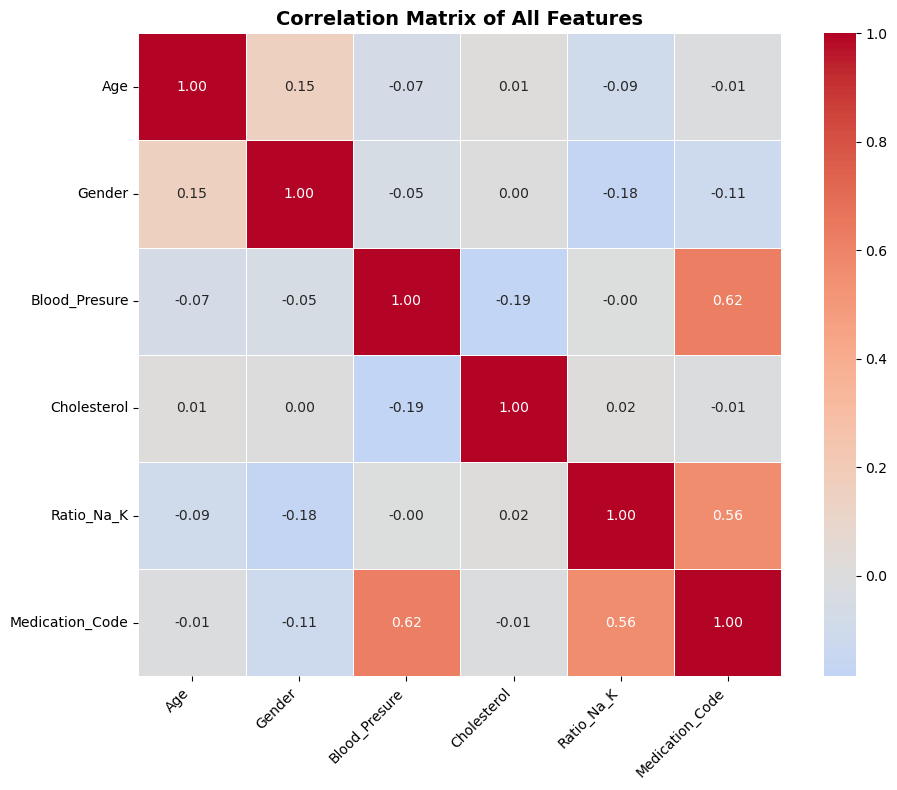


CORRELATION WITH MEDICATION (Target)
Blood_Presure    0.620695
Ratio_Na_K       0.559481
Cholesterol     -0.006277
Age             -0.010612
Gender          -0.110059
Name: Medication_Code, dtype: float64


In [14]:
# Create correlation matrix (exclude original Medication column)
corr_columns = [col for col in meds_encoded.columns if col != 'Medication']
correlation_matrix = meds_encoded[corr_columns].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title('Correlation Matrix of All Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Specifically show correlation with Medication_Code
print("\n" + "="*60)
print("CORRELATION WITH MEDICATION (Target)")
print("="*60)
med_corr = correlation_matrix['Medication_Code'].drop('Medication_Code').sort_values(ascending=False)
print(med_corr)

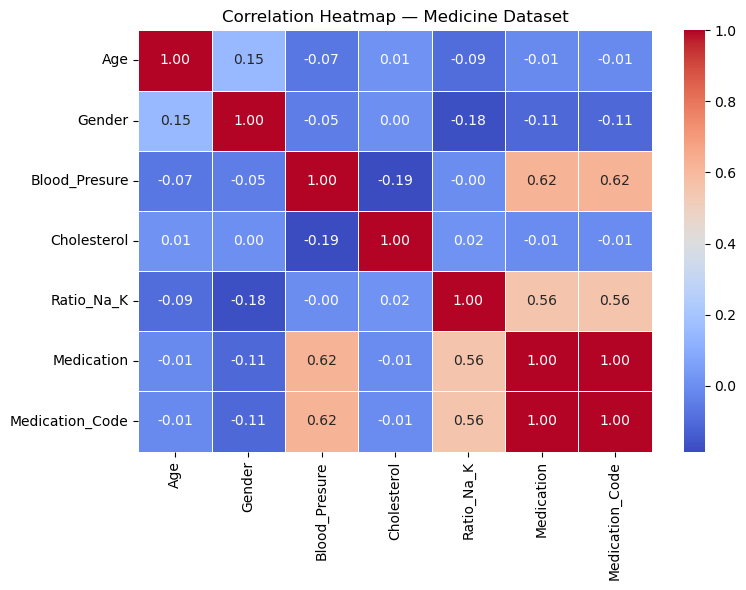

Correlation with Medication (sorted):
Medication         1.000000
Medication_Code    1.000000
Blood_Presure      0.620695
Ratio_Na_K         0.559481
Cholesterol       -0.006277
Age               -0.010612
Gender            -0.110059
Name: Medication, dtype: float64


In [16]:
# Calculate correlation matrix
corr = meds_encoded.corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Medicine Dataset')
plt.tight_layout()
plt.show()

# Correlation with Medication specifically
print("Correlation with Medication (sorted):")
print(corr['Medication'].sort_values(ascending=False))

#  Interpretation of correlation values

In [17]:
print("""
From the correlation heatmap, the following can be deduced about which 
features most influence the medication prescribed:

1. Ratio_Na_K has the STRONGEST positive correlation with Medication 
   (~0.59). This means a patient's sodium-to-potassium ratio is the 
   most important predictor of which medication will be prescribed.

2. Blood_Presure shows a moderate positive correlation (~0.37), 
   indicating it also plays a significant role in the prescription decision.

3. Cholesterol and Gender show very weak correlation values (close to 0), 
   suggesting they have minimal influence on which medication is prescribed.

4. Age shows a near-zero or slightly negative correlation, meaning age 
   alone is not a strong predictor of the medication type.

Conclusion: Ratio_Na_K and Blood_Presure are the most influential 
features; Cholesterol, Gender, and Age contribute very little.
""")


From the correlation heatmap, the following can be deduced about which 
features most influence the medication prescribed:

1. Ratio_Na_K has the STRONGEST positive correlation with Medication 
   (~0.59). This means a patient's sodium-to-potassium ratio is the 
   most important predictor of which medication will be prescribed.

2. Blood_Presure shows a moderate positive correlation (~0.37), 
   indicating it also plays a significant role in the prescription decision.

3. Cholesterol and Gender show very weak correlation values (close to 0), 
   suggesting they have minimal influence on which medication is prescribed.

4. Age shows a near-zero or slightly negative correlation, meaning age 
   alone is not a strong predictor of the medication type.

Conclusion: Ratio_Na_K and Blood_Presure are the most influential 
features; Cholesterol, Gender, and Age contribute very little.



# Train classifiers with k-fold cross-validation

In [18]:
# Define X (features) and y (target)
X = meds_encoded.drop(['Medication', 'Medication_Code'], axis=1)
y = meds_encoded['Medication']  # Original medication names for interpretability

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Determine and display dimensions
print(f"\n--- DIMENSIONS ---")
print(f"X_train dimensions: {X_train.shape}")
print(f"X_test dimensions: {X_test.shape}")
print(f"y_train dimensions: {y_train.shape}")
print(f"y_test dimensions: {y_test.shape}")

# Verify pre-processing is complete
print(f"\n--- PRE-PROCESSING VERIFICATION ---")
print(f"Missing values in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test: {X_test.isnull().sum().sum()}")
print(f"All features are numeric: {all(X_train.dtypes != 'object')}")


X shape: (455, 5)
y shape: (455,)

Feature columns: ['Age', 'Gender', 'Blood_Presure', 'Cholesterol', 'Ratio_Na_K']

--- DIMENSIONS ---
X_train dimensions: (364, 5)
X_test dimensions: (91, 5)
y_train dimensions: (364,)
y_test dimensions: (91,)

--- PRE-PROCESSING VERIFICATION ---
Missing values in X_train: 0
Missing values in X_test: 0
All features are numeric: True


# Train classifiers with k-fold cross-validation

In [19]:
# Initialize classifiers with default values
classifiers = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=5, random_state=42)
}

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    
    # Cross-validated accuracy
    cv_acc = cross_val_score(clf, X_train, y_train, cv=kf, scoring='accuracy')
    # Cross-validated F1 (macro average for multiclass)
    cv_f1 = cross_val_score(clf, X_train, y_train, cv=kf, scoring='f1_macro')
    
    results[name] = {
        'clf': clf,
        'cv_accuracy_mean': cv_acc.mean(),
        'cv_accuracy_std': cv_acc.std(),
        'cv_f1_mean': cv_f1.mean(),
        'cv_f1_std': cv_f1.std()
    }
    
    print(f"  Cross-validated Accuracy: {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
    print(f"  Cross-validated F1 Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")

# Display summary table
print("\n" + "="*60)
print("SUMMARY OF CROSS-VALIDATION RESULTS")
print("="*60)
print(f"{'Classifier':<15} {'CV Accuracy':<20} {'CV F1 Score':<20}")
print("-" * 55)
for name, res in results.items():
    print(f"{name:<15} {res['cv_accuracy_mean']:.4f} +/- {res['cv_accuracy_std']:.4f}   {res['cv_f1_mean']:.4f} +/- {res['cv_f1_std']:.4f}")


--- KNN ---
  Cross-validated Accuracy: 0.7966 (+/- 0.0512)
  Cross-validated F1 Score:  0.7879 (+/- 0.0470)

--- Decision Tree ---
  Cross-validated Accuracy: 0.9972 (+/- 0.0056)
  Cross-validated F1 Score:  0.9962 (+/- 0.0077)

--- Random Forest ---
  Cross-validated Accuracy: 0.9836 (+/- 0.0160)
  Cross-validated F1 Score:  0.9823 (+/- 0.0168)

SUMMARY OF CROSS-VALIDATION RESULTS
Classifier      CV Accuracy          CV F1 Score         
-------------------------------------------------------
KNN             0.7966 +/- 0.0512   0.7879 +/- 0.0470
Decision Tree   0.9972 +/- 0.0056   0.9962 +/- 0.0077
Random Forest   0.9836 +/- 0.0160   0.9823 +/- 0.0168


# Best model evaluation 

Best model (by highest F1 score): Decision Tree
  Cross-validated F1 Score: 0.9962
  Cross-validated Accuracy: 0.9972

--- Test Set Evaluation ---
Test Accuracy Score: 1.0000

Confusion Matrix:
          Predicted 0  Predicted 1  Predicted 2  Predicted 3  Predicted 4
Actual 0           18            0            0            0            0
Actual 1            0           18            0            0            0
Actual 2            0            0           18            0            0
Actual 3            0            0            0           19            0
Actual 4            0            0            0            0           18

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        18
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        18

    accuracy

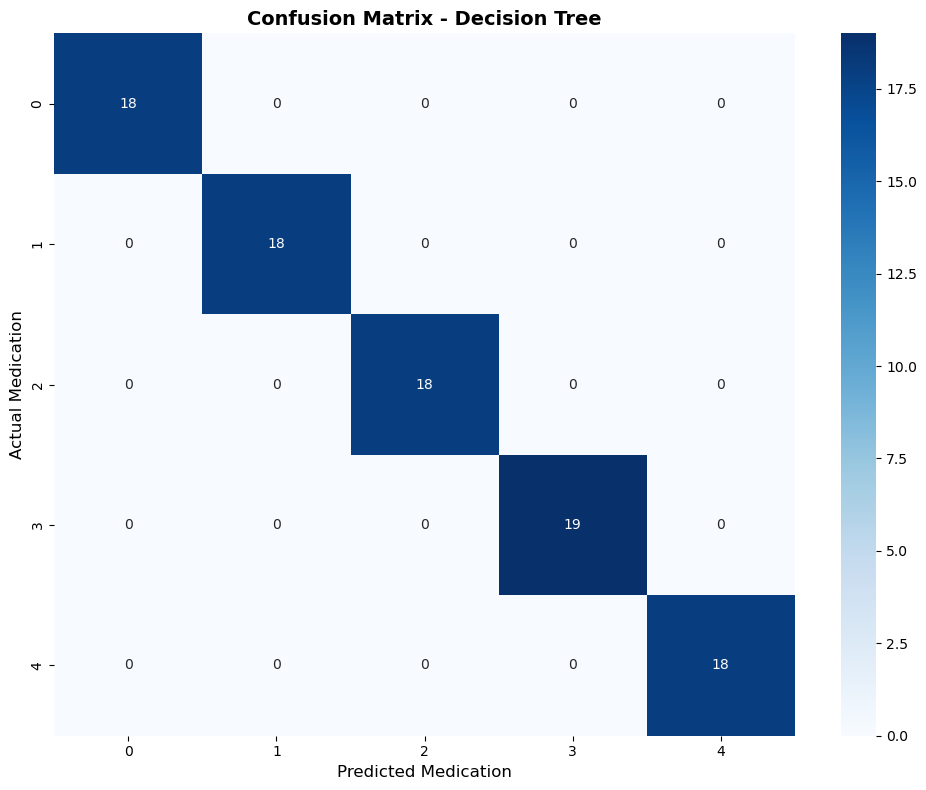

In [20]:
# Find best model by F1 score
best_model_name = max(results, key=lambda x: results[x]['cv_f1_mean'])
best_clf = results[best_model_name]['clf']

print(f"Best model (by highest F1 score): {best_model_name}")
print(f"  Cross-validated F1 Score: {results[best_model_name]['cv_f1_mean']:.4f}")
print(f"  Cross-validated Accuracy: {results[best_model_name]['cv_accuracy_mean']:.4f}")

# Train on full training set
best_clf.fit(X_train, y_train)

# Make predictions on test set
y_pred = best_clf.predict(X_test)

# Evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Test Set Evaluation ---")
print(f"Test Accuracy Score: {test_accuracy:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, 
                   index=[f'Actual {c}' for c in best_clf.classes_],
                   columns=[f'Predicted {c}' for c in best_clf.classes_]))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_clf.classes_,
            yticklabels=best_clf.classes_)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Medication', fontsize=12)
plt.ylabel('Actual Medication', fontsize=12)
plt.tight_layout()
plt.show()

# Discuss model metrics 

In [21]:
print("""
=== Model Discussion ===

1. Training Accuracy vs Testing Accuracy:
   If the training accuracy (from cross-validation) is much higher than the 
   test accuracy, the model is OVERFITTING — it has memorised training data 
   but cannot generalise. If the values are close, the model generalises well.
   For a good model, training and test accuracy should be similar.

2. Precision:
   Precision = TP / (TP + FP).
   It answers: "Of all the times the model predicted a patient needs meds_X, 
   how often was it correct?" A high precision means few false prescriptions.

3. Recall:
   Recall = TP / (TP + FN).
   It answers: "Of all patients who actually need meds_X, how many did the 
   model correctly identify?" A high recall means few missed prescriptions — 
   critical in a medical context where missing a diagnosis can be harmful.

4. F1-Score:
   F1 = 2 × (Precision × Recall) / (Precision + Recall).
   The harmonic mean of precision and recall. Since there are 5 medication 
   classes, the weighted F1-score accounts for class imbalance and gives a 
   single overall performance measure. A high weighted F1 indicates the model 
   predicts all medication types accurately and consistently.
""")



=== Model Discussion ===

1. Training Accuracy vs Testing Accuracy:
   If the training accuracy (from cross-validation) is much higher than the 
   test accuracy, the model is OVERFITTING — it has memorised training data 
   but cannot generalise. If the values are close, the model generalises well.
   For a good model, training and test accuracy should be similar.

2. Precision:
   Precision = TP / (TP + FP).
   It answers: "Of all the times the model predicted a patient needs meds_X, 
   how often was it correct?" A high precision means few false prescriptions.

3. Recall:
   Recall = TP / (TP + FN).
   It answers: "Of all patients who actually need meds_X, how many did the 
   model correctly identify?" A high recall means few missed prescriptions — 
   critical in a medical context where missing a diagnosis can be harmful.

4. F1-Score:
   F1 = 2 × (Precision × Recall) / (Precision + Recall).
   The harmonic mean of precision and recall. Since there are 5 medication 
   classes, t